# Toy Squares Paper Plots

This notebook loads `main_result_LTLDOG` and builds the paper-facing Toy Squares figures:

1. the compact Toy Squares layout with one base Diffusion Policy rollout per reached block,
2. a square metrics panel with success rate on top and environment steps below,
3. one shared-axis rollout example comparing LTLDoG and `hint_squared`,
4. a final strip arranging those three square panels next to each other.


In [9]:
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox

REPO_ROOT = Path('/home/moritz/src/guided-diffusion')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from toy_squares.toy_squares_utils import _draw_blocks as draw_toy_blocks
from toy_squares.toy_squares_utils import _flip_y as flip_toy_y

RESULT_ROOT = REPO_ROOT / 'outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG'
PLOT_DIR = RESULT_ROOT / 'paperplots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

LTLDOG_METHOD = 'ltldog_h128_compact_full_exec_tau0p001_scale0p10_g20'
INCLUDE_TELOGRAF = True
EXTENDED_HORIZONS = [1, 2, 3, 4, 5]
DISPLAY_HORIZONS = EXTENDED_HORIZONS

# This is the LaTeX textwidth Moritz gave.  The final composite is saved at
# this exact width, so LaTeX should not need to shrink it further.
LATEX_TEXTWIDTH_PT = 397.48499
PT_PER_IN = 72.27
TEXTWIDTH_IN = LATEX_TEXTWIDTH_PT / PT_PER_IN
SQUARE_SIDE_IN = TEXTWIDTH_IN
FOUR_SQUARE_ROW_HEIGHT_IN = 0.43 * TEXTWIDTH_IN
# Manual row-layout knobs for the final four-panel figure.  The plotted
# square frames are equal-size and equal-spaced; metric y labels live in the
# inter-panel gaps instead of shrinking the metric panels.
FOUR_PANEL_AXIS_SIDE_IN = 1.00
FOUR_PANEL_LEFT_MARGIN_IN = 0.37
FOUR_PANEL_RIGHT_MARGIN_IN = 0.08
FOUR_PANEL_FRAME_GAP_IN = (
    TEXTWIDTH_IN - FOUR_PANEL_LEFT_MARGIN_IN - FOUR_PANEL_RIGHT_MARGIN_IN - 4 * FOUR_PANEL_AXIS_SIDE_IN
) / 3
FOUR_PANEL_AXIS_BOTTOM_IN = 0.64
FOUR_PANEL_SEPARATOR_TOP_INSET_IN = -0.05
FOUR_PANEL_SEPARATOR_BOTTOM_INSET_IN = -0.05
FOUR_PANEL_CROP_BOTTOM_IN = 0.169
FOUR_PANEL_CROP_TOP_IN = 1.775
FIG_DPI = 300
PLAIN_BASE_DPI = 1200

BLOCK_ORDER = ['blue', 'red', 'green', 'yellow']
BLOCK_COLORS = {
    'blue': '#4f79a7',
    'red': '#b85f5a',
    'green': '#5e9c73',
    'yellow': '#c8a84a',
}

OUR_BLUE = '#275fca'
OUR_BLUE_LIGHT = '#7c9ce6'
LTLDOG_GRAY = '#5f6368'
LTLDOG_GRAY_LIGHT = '#9aa0a6'
TELOGRAF_COLOR = '#a68e45'
TELOGRAF_LIGHT = '#c9bc7f'
AXIS_GRAY = '#8a8a8a'
PANEL_FRAME_LW = 0.9
COMMON_ENV_XLIM = (-0.57, 0.57)
COMMON_ENV_YLIM = (-0.52, 0.62)
ORIGINAL_ENV_XLIM = (-0.74, 0.74)
ORIGINAL_ENV_YLIM = (-0.74, 0.74)
AGENT_RADIUS = 0.09
CONTACT_DOT_RADIUS = 0.035
CONTACT_DOT_MARKER_SIZE = 17
BLOCK_BASE_RADIUS = 0.145
BLOCK_RADIUS = BLOCK_BASE_RADIUS + AGENT_RADIUS - CONTACT_DOT_RADIUS
TELOGRAF_IMAGINED = {1: 1.00, 2: 0.00, 3: 0.00, 4: 0.00, 5: 0.00}
TELOGRAF_ACTUAL = {1: 0.85, 2: 0.00, 3: 0.00, 4: 0.00, 5: 0.00}
TELOGRAF_MEAN_STEPS = {1: 21.85, 2: 49.75, 3: 64.00, 4: 64.00, 5: 64.00}


plt.rcParams.update({
    # Approximate LaTeX \texttt{} by preferring Computer Modern/CMU typewriter,
    # then falling back to the bundled DejaVu mono face.
    'font.family': 'monospace',
    'font.monospace': ['Computer Modern Typewriter', 'CMU Typewriter Text', 'DejaVu Sans Mono'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 6.5,
    'axes.titlesize': 7,
    'axes.titleweight': 'normal',
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
    'figure.dpi': FIG_DPI,
    'savefig.dpi': FIG_DPI,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def save_fig(fig, stem, tight=True):
    save_kwargs = {'bbox_inches': 'tight', 'pad_inches': 0.02} if tight else {}
    fig.savefig(PLOT_DIR / f'{stem}.png', **save_kwargs)
    fig.savefig(PLOT_DIR / f'{stem}.pdf', **save_kwargs)


def save_fig_vertical_crop(fig, stem, bottom, top):
    # Preserve the exact textwidth and all internal panel geometry, but crop
    # unused vertical canvas.  Coordinates are in figure inches from bottom.
    fig_w, _ = fig.get_size_inches()
    crop = Bbox.from_extents(0.0, float(bottom), float(fig_w), float(top))
    fig.savefig(PLOT_DIR / f'{stem}.png', bbox_inches=crop, pad_inches=0.0)
    fig.savefig(PLOT_DIR / f'{stem}.pdf', bbox_inches=crop, pad_inches=0.0)

def latest_vector(value):
    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim >= 2:
        arr = arr[-1]
    return arr.reshape(-1)


def load_trajectory(run_dir):
    with np.load(run_dir / 'low_level_obs.npz', allow_pickle=True) as data:
        agent_pos = np.asarray(data['agent_pos'])
    trajectory = np.stack([latest_vector(item) for item in agent_pos], axis=0)
    return flip_toy_y(trajectory)


def load_predicted_trajectory(run_dir):
    with np.load(run_dir / 'trace.npz', allow_pickle=True) as data:
        predicted = np.asarray(data.get('predicted', np.zeros((0, 12))), dtype=np.float32)
    if predicted.size == 0:
        return np.zeros((0, 2), dtype=np.float32)
    # LTLDoG stores full transition vectors [action(2), observation(10)].  The
    # first two observation entries are the imagined agent position.
    return flip_toy_y(predicted[:, 2:4])


def setup_blocks(setup_state):
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    agent = setup_state[:2] / 256.0 - 1.0
    angles = np.asarray(setup_state[10:14], dtype=float) if setup_state.shape[0] >= 14 else np.zeros(4)
    return flip_toy_y(blocks), flip_toy_y(agent), -angles


def square_zoom_limits(setup_state, trajectories=(), pad=0.14, min_half_width=0.48):
    blocks, agent, _ = setup_blocks(setup_state)
    point_sets = [blocks, agent[None]]
    for traj in trajectories:
        traj = np.asarray(traj)
        if traj.size:
            point_sets.append(traj[:, :2])
    pts = np.concatenate(point_sets, axis=0)
    lo = pts.min(axis=0)
    hi = pts.max(axis=0)
    center = 0.5 * (lo + hi)
    half = max(float(np.max(hi - lo)) * 0.5 + pad, min_half_width)
    return (center[0] - half, center[0] + half), (center[1] - half, center[1] + half)


def style_env_axis(ax, setup_state, trajectories=(), pad=0.14, min_half_width=0.48, title=None,
                   show_frame=True, xlim=COMMON_ENV_XLIM, ylim=COMMON_ENV_YLIM):
    blocks, agent, angles = setup_blocks(setup_state)
    colors = [BLOCK_COLORS[name] for name in BLOCK_ORDER]
    draw_toy_blocks(ax, blocks, angles, colors, radius=BLOCK_RADIUS, alpha=0.96, zorder=4)
    ax.scatter([agent[0]], [agent[1]], s=30, marker='o', c='#2f2f2f', alpha=0.95,
               edgecolors='white', linewidths=0.35, zorder=5)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.axis('off')
    if show_frame:
        frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False,
                              edgecolor='black', linewidth=PANEL_FRAME_LW,
                              clip_on=False, zorder=20)
        ax.add_patch(frame)
    if title:
        set_panel_title(ax, title)


def faded_path(ax, trajectory, color, linewidth=0.725, alpha=(0.18, 0.92), linestyle='solid', zorder=2):
    trajectory = np.asarray(trajectory, dtype=float)
    if len(trajectory) <= 1:
        return None
    segments = np.stack([trajectory[:-1], trajectory[1:]], axis=1)
    rgba = np.array(to_rgba(color))
    colors = np.tile(rgba, (len(segments), 1))
    colors[:, 3] = np.linspace(alpha[0], alpha[1], len(segments))
    line = LineCollection(segments, colors=colors, linewidths=linewidth, linestyles=linestyle,
                          capstyle='butt', joinstyle='round', zorder=zorder)
    ax.add_collection(line)
    return line


def style_metric_frame(ax):
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(PANEL_FRAME_LW)


def set_panel_title(ax, title):
    # Final row axes are manually positioned, so the title cannot resize the
    # square frames.  Keep wrapping off to avoid title-driven layout surprises.
    text = ax.set_title(title, pad=3.0, fontsize=7, fontweight='normal', wrap=False)
    text.set_clip_on(False)
    return text


def paper_legend_handles():
    marker_style = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
    handles = [
        Line2D([0], [0], color=OUR_BLUE, lw=0.8, label='hint²', **marker_style),
        Line2D([0], [0], color=LTLDOG_GRAY, lw=0.725, label='LTLDoG (Rollout)', **marker_style),
        Line2D([0], [0], color=LTLDOG_GRAY_LIGHT, lw=0.675, linestyle='--',
               label='LTLDoG (Planning)', **marker_style),
    ]
    if INCLUDE_TELOGRAF:
        handles.extend([
            Line2D([0], [0], color=TELOGRAF_COLOR, lw=0.725, label='TeLoGraF (Rollout)', **marker_style),
            Line2D([0], [0], color=TELOGRAF_LIGHT, lw=0.675, linestyle='--',
                   label='TeLoGraF (Planning)', **marker_style),
        ])
    return handles


def horizon_dirs():
    return sorted([p for p in RESULT_ROOT.glob('horizon_*') if p.is_dir()])


def parse_horizon(path):
    return int(path.name.split('_')[1])


def method_summary(method, horizon):
    for hdir in horizon_dirs():
        if parse_horizon(hdir) == int(horizon):
            path = hdir / method / 'summary.json'
            if path.exists():
                summary = load_json(path)
                summary['_summary_path'] = str(path)
                summary['_method_dir'] = str(path.parent)
                return summary
    raise FileNotFoundError(f'No summary for method={method}, horizon={horizon}')


def all_method_summaries(method):
    rows = []
    for hdir in horizon_dirs():
        path = hdir / method / 'summary.json'
        if path.exists():
            summary = load_json(path)
            summary['_summary_path'] = str(path)
            summary['_method_dir'] = str(path.parent)
            rows.append(summary)
    return sorted(rows, key=lambda row: int(row['ltl_horizon']))


def record_run_dir(summary, record):
    run_dir = Path(record.get('run_dir', ''))
    if run_dir.exists():
        return run_dir
    return Path(summary['_method_dir']) / f"rollout_{int(record['rollout_idx']):03d}"


def load_diagnostic_success():
    csv_path = RESULT_ROOT / 'diagnostics_ltldog_imagined_vs_actual' / 'combined_success_summary.csv'
    if not csv_path.exists():
        return {}
    rows = {}
    with open(csv_path, 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            h = int(float(row['ltl_horizon']))
            rows[h] = {k: float(v) if v not in {'', None} else np.nan for k, v in row.items() if k != 'chain'}
            rows[h]['chain'] = row.get('chain', '')
    return rows


def collect_step_records():
    rows = []
    for method in ['ours', LTLDOG_METHOD]:
        for summary in all_method_summaries(method):
            for record in summary['records']:
                rows.append({
                    'method': 'ours' if method == 'ours' else 'ltldog',
                    'horizon': int(summary['ltl_horizon']),
                    'steps': int(record['steps']),
                    'complete': bool(record['complete']),
                    'chain': ' -> '.join(summary['chain']),
                })
    return rows


def mean_steps_by_horizon(method):
    if method == 'telograf':
        return dict(TELOGRAF_MEAN_STEPS)
    values = {}
    summary_method = LTLDOG_METHOD if method == 'ltldog' else method
    for summary in all_method_summaries(summary_method):
        horizon = int(summary['ltl_horizon'])
        if horizon not in EXTENDED_HORIZONS:
            continue
        steps = [float(record['steps']) for record in summary['records']]
        values[horizon] = float(np.mean(steps)) if steps else np.nan
    return values


def mark_first_hit(ax, pos, label, color, text=None, dx=0.012, dy=0.012, zorder=12):
    ax.scatter([pos[0]], [pos[1]], s=CONTACT_DOT_MARKER_SIZE, facecolors='white', edgecolors=color,
               linewidths=0.8, zorder=zorder)
    if text:
        ax.text(pos[0] + dx, pos[1] + dy, text, color=color, fontsize=5.5,
                ha='left', va='bottom', zorder=zorder + 1)


def mark_sequence_hits(ax, run_dir, color, text_offset=(0.012, 0.012), max_stage=None, zorder=12):
    summary = load_json(run_dir / 'rollout_summary.json')
    traj = load_trajectory(run_dir)
    for idx, reach in enumerate(summary.get('reaches', []), start=1):
        if max_stage is not None and idx > max_stage:
            continue
        t = min(int(reach['t']), len(traj) - 1)
        mark_first_hit(ax, traj[t], reach['label'], color, text=None, dx=text_offset[0], dy=text_offset[1], zorder=zorder)


## 1. Base Layout and Base Diffusion Policy Rollouts

One unguided/base Diffusion Policy rollout is shown for each block it reaches.  Each trajectory is truncated shortly after the first hit so the panel stays readable.


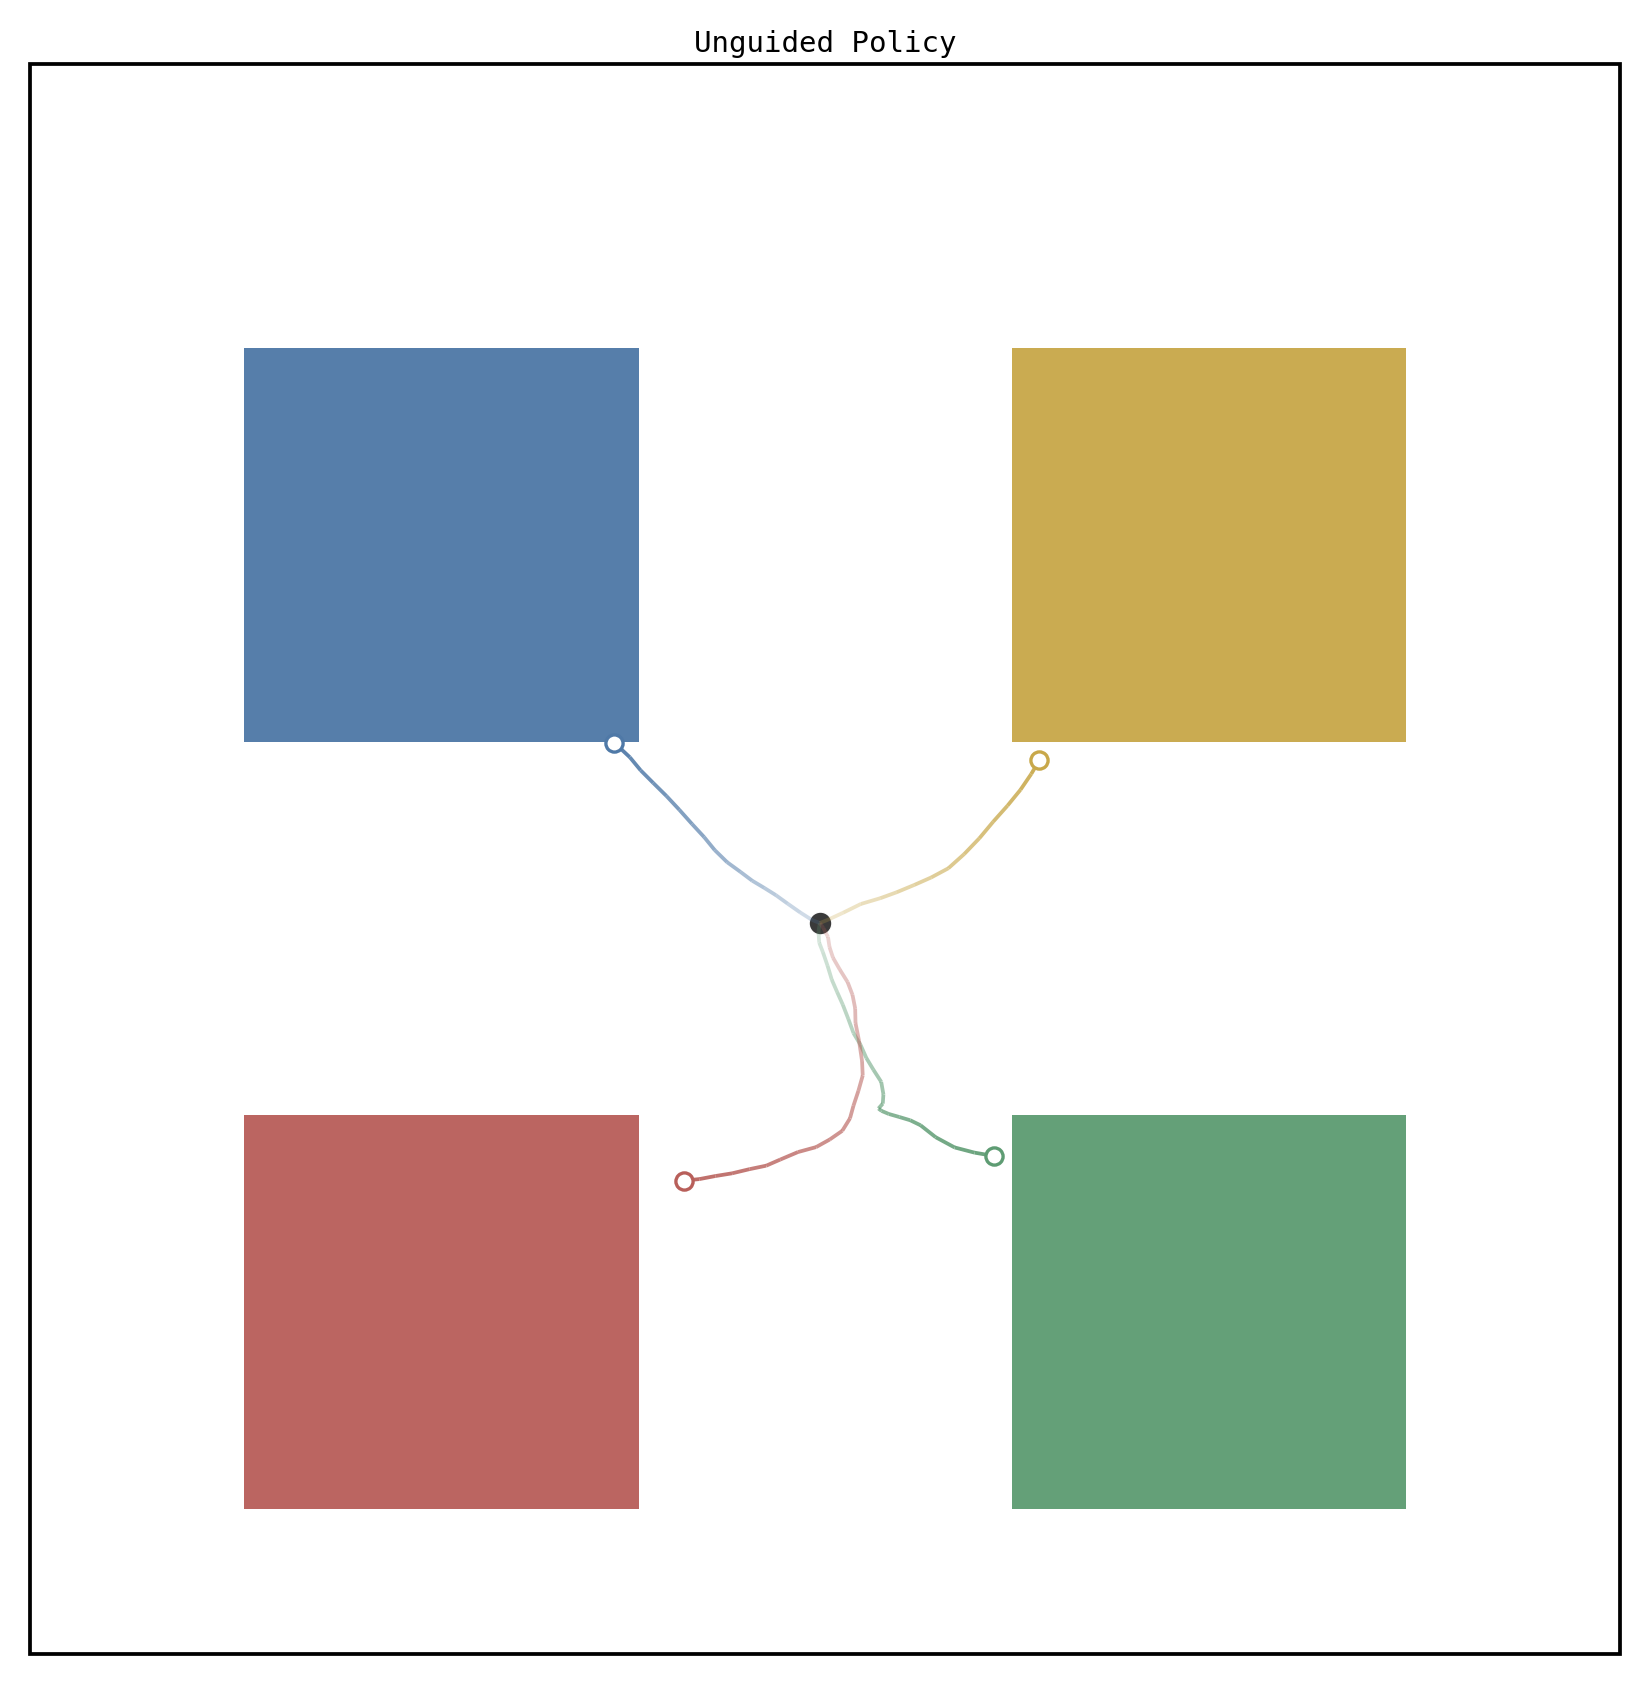

saved: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/paperplots/fig1_base_dp_layout_rollouts.png


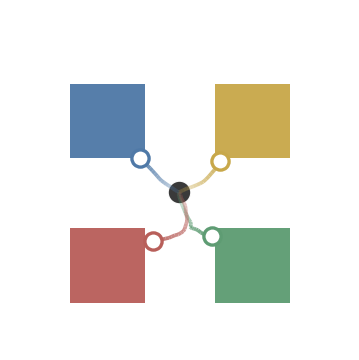

saved: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/paperplots/fig1_base_dp_layout_rollouts_plain.png


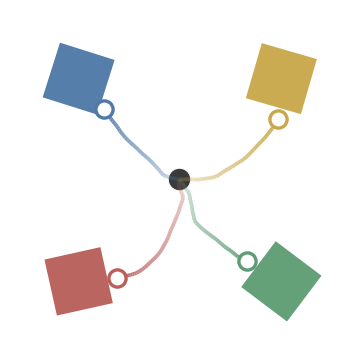

saved: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/paperplots/fig1_base_dp_layout_rollouts_original_plain.png


In [10]:
BASE_ROLLOUT_BY_BLOCK = {
    'blue': 7,
    'yellow': 9,
    'green': 3,
    'red': 2,
}
BASE_ORIGINAL_SUBDIR = 'base_dp_rollouts_original'
BASE_ORIGINAL_ROLLOUT_BY_BLOCK = {
    'blue': 35,
    'yellow': 26,
    'green': 17,
    'red': 2,
}
BASE_AFTER_HIT_STEPS = 0


def base_rollout_trace(block, base_subdir='base_dp_rollouts', rollout_by_block=None):
    if rollout_by_block is None:
        rollout_by_block = BASE_ROLLOUT_BY_BLOCK
    base_root = RESULT_ROOT / base_subdir
    rollout_idx = rollout_by_block[block]
    run_dir = base_root / f'rollout_{rollout_idx:03d}'
    summary = load_json(run_dir / 'rollout_summary.json')
    traj = load_trajectory(run_dir)
    hit_t = int(summary['first_hits'][block])
    end_t = min(len(traj) - 1, hit_t + BASE_AFTER_HIT_STEPS)
    return run_dir, summary, traj[:end_t + 1], hit_t


def plot_base_dp_panel(ax, legend=True, title='Unguided Policy', show_frame=True,
                       base_subdir='base_dp_rollouts', rollout_by_block=None,
                       xlim=COMMON_ENV_XLIM, ylim=COMMON_ENV_YLIM):
    if rollout_by_block is None:
        rollout_by_block = BASE_ROLLOUT_BY_BLOCK
    setup_state = np.load(RESULT_ROOT / base_subdir / 'rollout_000' / 'setup_state.npy')
    traces = []
    for block in rollout_by_block:
        _, _, traj, _ = base_rollout_trace(block, base_subdir=base_subdir, rollout_by_block=rollout_by_block)
        traces.append(traj)
    style_env_axis(ax, setup_state, trajectories=traces, pad=0.13, min_half_width=0.48,
                   title=title, show_frame=show_frame, xlim=xlim, ylim=ylim)

    legend_handles = []
    for block, rollout_idx in rollout_by_block.items():
        run_dir, summary, traj, hit_t = base_rollout_trace(block, base_subdir=base_subdir, rollout_by_block=rollout_by_block)
        faded_path(ax, traj, BLOCK_COLORS[block], linewidth=0.9, alpha=(0.22, 0.92), zorder=6)
        mark_first_hit(ax, traj[-1], block, BLOCK_COLORS[block], text=None)
        legend_handles.append(Line2D([0], [0], color=BLOCK_COLORS[block], lw=0.9, label=block))

    if legend:
        ax.legend(handles=legend_handles, loc='lower left', frameon=False, ncol=2,
                  handlelength=1.0, borderaxespad=0.2, columnspacing=0.7)


fig, ax = plt.subplots(figsize=(SQUARE_SIDE_IN, SQUARE_SIDE_IN), constrained_layout=True)
plot_base_dp_panel(ax, legend=False)
save_fig(fig, 'fig1_base_dp_layout_rollouts', tight=False)
plt.show()
print('saved:', PLOT_DIR / 'fig1_base_dp_layout_rollouts.png')

fig_plain = plt.figure(figsize=(FOUR_PANEL_AXIS_SIDE_IN, FOUR_PANEL_AXIS_SIDE_IN), constrained_layout=False)
ax_plain = fig_plain.add_axes([0, 0, 1, 1])
plot_base_dp_panel(ax_plain, legend=False, title=None, show_frame=False)
fig_plain.savefig(PLOT_DIR / 'fig1_base_dp_layout_rollouts_plain.png', dpi=PLAIN_BASE_DPI, pad_inches=0.0)
fig_plain.savefig(PLOT_DIR / 'fig1_base_dp_layout_rollouts_plain.pdf', pad_inches=0.0)
plt.show()
print('saved:', PLOT_DIR / 'fig1_base_dp_layout_rollouts_plain.png')

fig_plain_original = plt.figure(figsize=(FOUR_PANEL_AXIS_SIDE_IN, FOUR_PANEL_AXIS_SIDE_IN), constrained_layout=False)
ax_plain_original = fig_plain_original.add_axes([0, 0, 1, 1])
plot_base_dp_panel(
    ax_plain_original,
    legend=False,
    title=None,
    show_frame=False,
    base_subdir=BASE_ORIGINAL_SUBDIR,
    rollout_by_block=BASE_ORIGINAL_ROLLOUT_BY_BLOCK,
    xlim=ORIGINAL_ENV_XLIM,
    ylim=ORIGINAL_ENV_YLIM,
)
fig_plain_original.savefig(PLOT_DIR / 'fig1_base_dp_layout_rollouts_original_plain.png', dpi=PLAIN_BASE_DPI, pad_inches=0.0)
fig_plain_original.savefig(PLOT_DIR / 'fig1_base_dp_layout_rollouts_original_plain.pdf', pad_inches=0.0)
plt.show()
print('saved:', PLOT_DIR / 'fig1_base_dp_layout_rollouts_original_plain.png')


## 2/3. Metrics Square

The top axis shows satisfaction over the first three LTL prefix lengths.  The dashed blue continuation marks the intended `hint_squared` capacity beyond the budget-limited measured horizon, and the vertical dashed line separates measured H1-H3 from that continuation.  The lower axis shows environment steps without method-specific x-offsets.


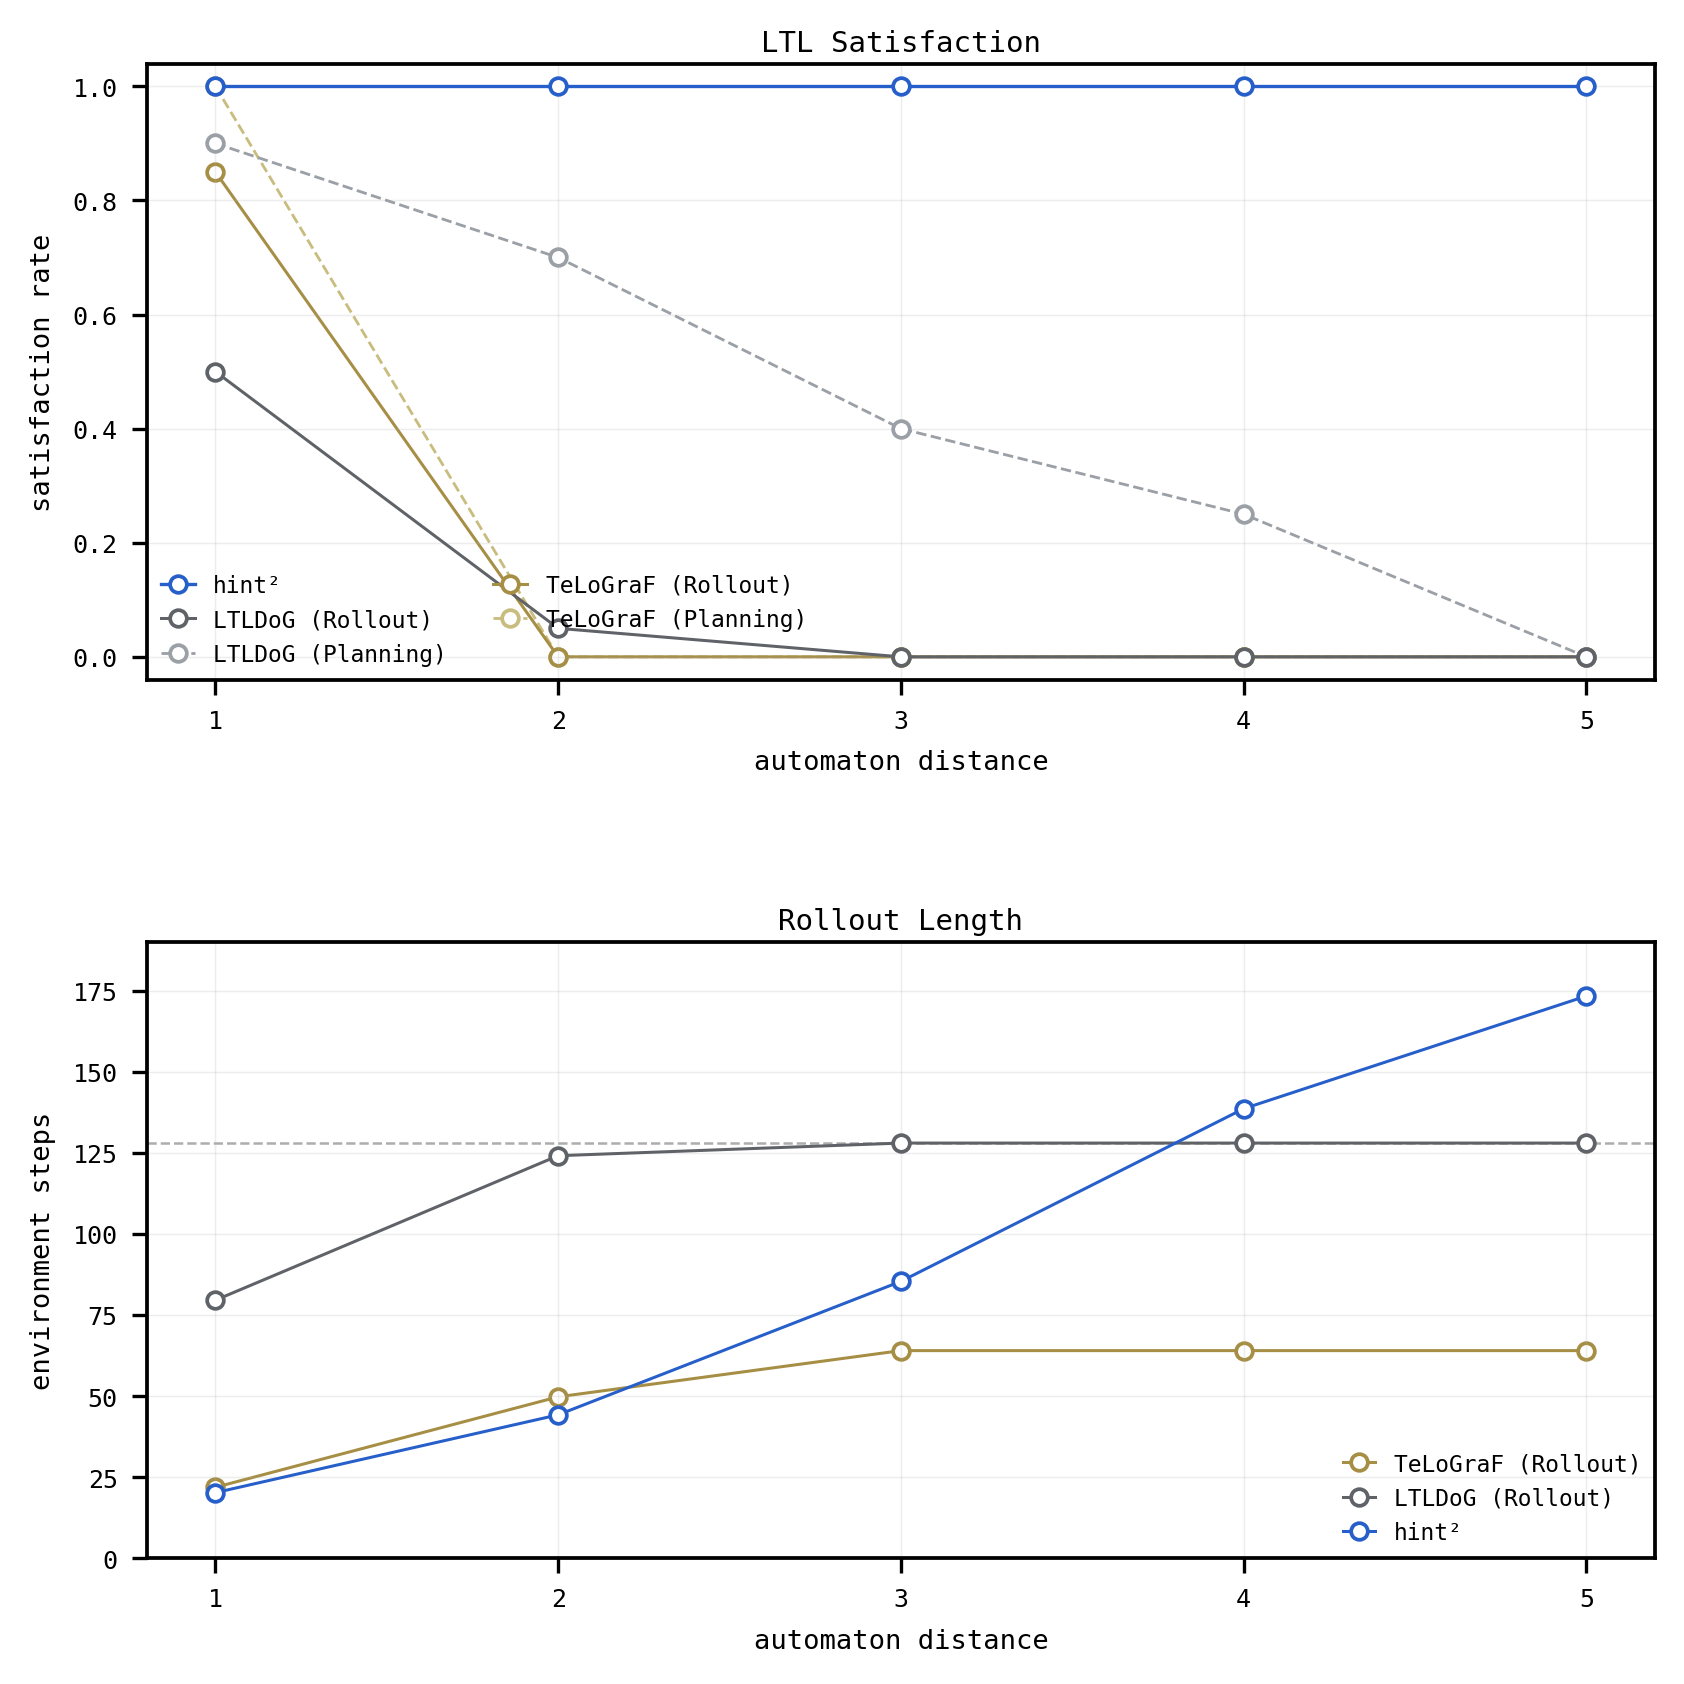

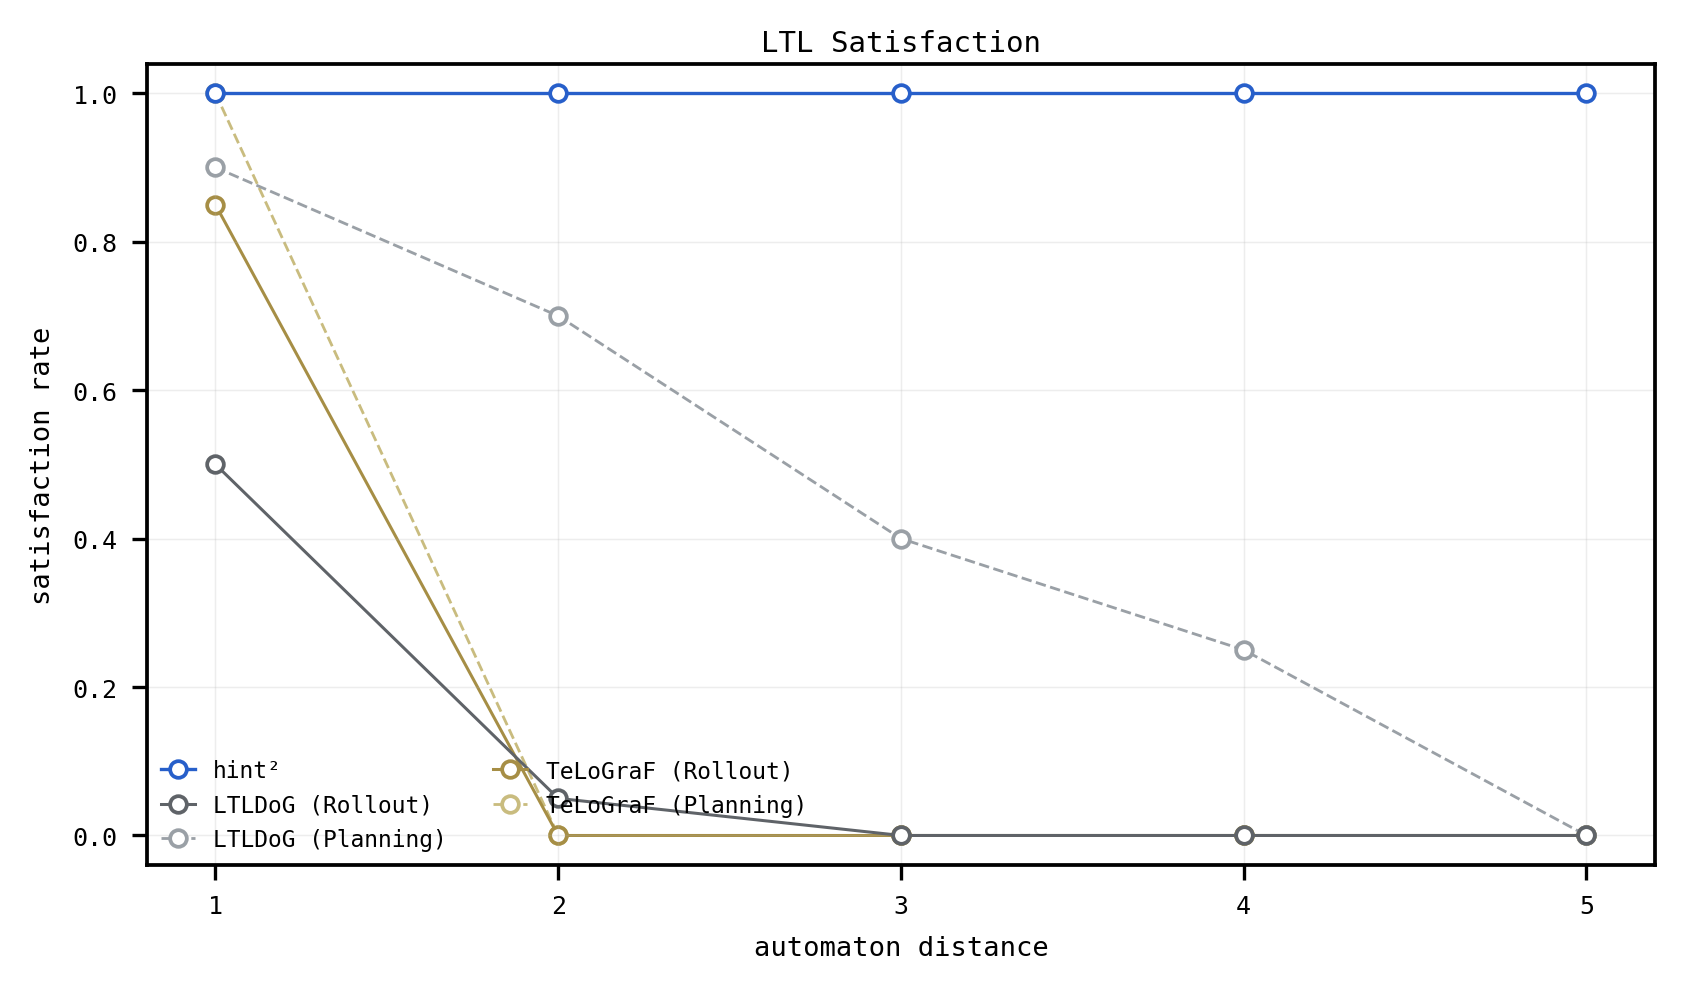

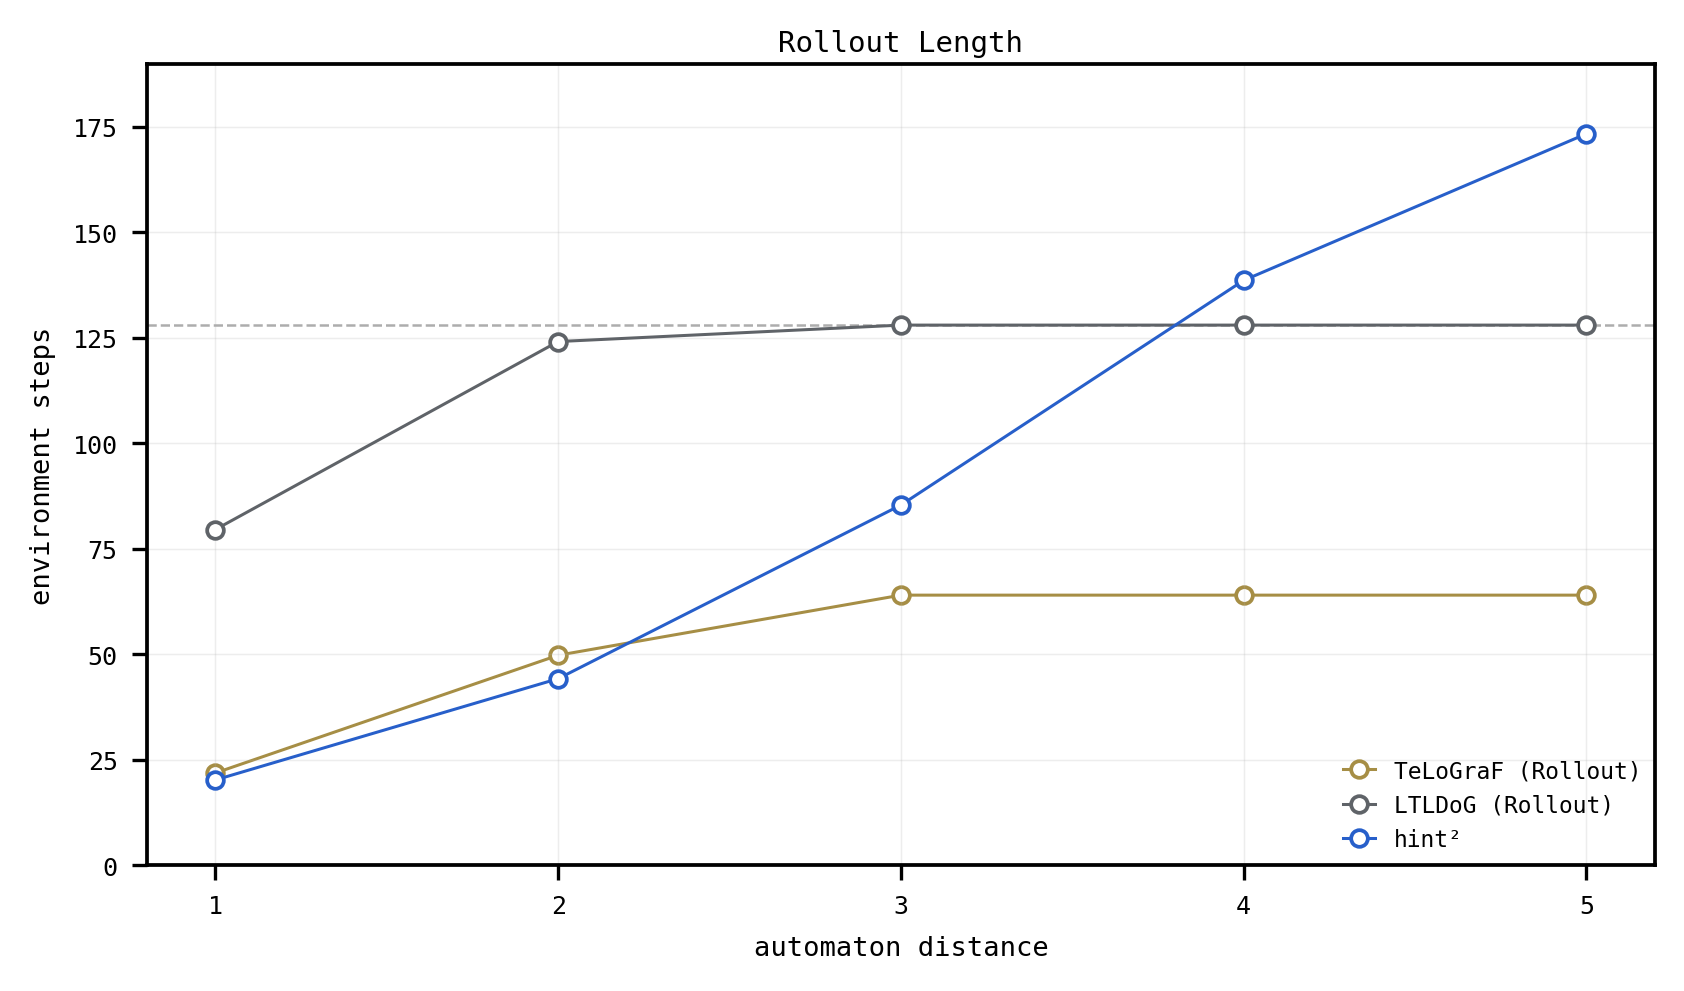

1 hint_squared 1.0 LTLDoG imagined 0.9 LTLDoG actual 0.5
  TeLoGraF imagined 1.0 TeLoGraF actual 0.85 TeLoGraF steps 21.85
2 hint_squared 1.0 LTLDoG imagined 0.7 LTLDoG actual 0.05
  TeLoGraF imagined 0.0 TeLoGraF actual 0.0 TeLoGraF steps 49.75
3 hint_squared 1.0 LTLDoG imagined 0.4 LTLDoG actual 0.0
  TeLoGraF imagined 0.0 TeLoGraF actual 0.0 TeLoGraF steps 64.0
4 hint_squared 1.0 LTLDoG imagined 0.25 LTLDoG actual 0.0
  TeLoGraF imagined 0.0 TeLoGraF actual 0.0 TeLoGraF steps 64.0
5 hint_squared 1.0 LTLDoG imagined 0.0 LTLDoG actual 0.0
  TeLoGraF imagined 0.0 TeLoGraF actual 0.0 TeLoGraF steps 64.0


In [3]:
def metric_values():
    diag = load_diagnostic_success()
    ours_summaries = all_method_summaries('ours')
    ltldog_summaries = all_method_summaries(LTLDOG_METHOD)
    ours_actual = {int(s['ltl_horizon']): float(s['success_rate']) for s in ours_summaries}
    ltldog_actual = {int(s['ltl_horizon']): float(s['success_rate']) for s in ltldog_summaries}
    ltldog_imagined = {
        h: diag.get(h, {}).get('ltldog_imagined_generated_blocks', np.nan)
        for h in EXTENDED_HORIZONS
    }
    return ours_actual, ltldog_actual, ltldog_imagined


def plot_success_axis(ax, legend=True, compact=False):
    ours_actual, ltldog_actual, ltldog_imagined = metric_values()
    h = EXTENDED_HORIZONS
    marker_kwargs_ours = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
    marker_kwargs_imagined = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
    marker_kwargs_actual = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
    marker_kwargs_telograf = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
    if INCLUDE_TELOGRAF:
        ax.plot(h, [TELOGRAF_IMAGINED.get(x, np.nan) for x in h], linewidth=0.675,
                linestyle='--', color=TELOGRAF_LIGHT, label='TeLoGraF (Planning)',
                zorder=1, **marker_kwargs_telograf)
        ax.plot(h, [TELOGRAF_ACTUAL.get(x, np.nan) for x in h], linewidth=0.725,
                color=TELOGRAF_COLOR, label='TeLoGraF (Rollout)', zorder=1.1, **marker_kwargs_telograf)
    ax.plot(h, [ltldog_imagined.get(x, np.nan) for x in h], linewidth=0.675,
            linestyle='--', color=LTLDOG_GRAY_LIGHT, label='LTLDoG (Planning)',
            zorder=2, **marker_kwargs_imagined)
    ax.plot(h, [ltldog_actual.get(x, np.nan) for x in h], linewidth=0.725,
            color=LTLDOG_GRAY, label='LTLDoG (Rollout)', zorder=2.1, **marker_kwargs_actual)
    ax.plot(h, [ours_actual.get(x, np.nan) for x in h], linewidth=0.8, color=OUR_BLUE,
            label='hint²', zorder=3, **marker_kwargs_ours)
    ax.set_xlim(0.8, 5.2)
    ax.set_ylim(-0.04, 1.04)
    ax.set_xticks([1, 2, 3, 4, 5])
    set_panel_title(ax, 'LTL Satisfaction')
    ax.set_xlabel('automaton distance')
    ax.set_ylabel('satisfaction rate')
    if compact:
        ax.tick_params(axis='both', pad=1.0)
        ax.xaxis.labelpad = 1.0
        ax.yaxis.labelpad = 1.0
    ax.grid(True, alpha=0.22, linewidth=0.35)
    style_metric_frame(ax)
    if legend:
        ax.legend(handles=paper_legend_handles(), loc='lower left', frameon=False,
                  ncol=2 if INCLUDE_TELOGRAF else 1,
                  handlelength=1.5, borderaxespad=0.2)


def plot_steps_axis(ax, legend=True, compact=False):
    method_specs = {}
    if INCLUDE_TELOGRAF:
        method_specs['telograf'] = ('TeLoGraF (Rollout)', TELOGRAF_COLOR, 0.725, 1)
    method_specs['ltldog'] = ('LTLDoG (Rollout)', LTLDOG_GRAY, 0.725, 2)
    method_specs['ours'] = ('hint²', OUR_BLUE, 0.725, 3)
    for method, (label, color, line_width, zorder) in method_specs.items():
        means = mean_steps_by_horizon(method)
        x = [h for h in EXTENDED_HORIZONS if h in means]
        y = [means[h] for h in x]
        marker_kwargs = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
        ax.plot(x, y, linewidth=line_width, color=color, label=label, zorder=zorder, **marker_kwargs)
    ax.axhline(128, color=AXIS_GRAY, linestyle='--', linewidth=0.6, alpha=0.70, zorder=0.8)
    ax.set_xlim(0.8, 5.2)
    ax.set_ylim(0, 190)
    ax.set_xticks(EXTENDED_HORIZONS)
    set_panel_title(ax, 'Rollout Length')
    ax.set_xlabel('automaton distance')
    ax.set_ylabel('env steps' if compact else 'environment steps')
    if compact:
        ax.tick_params(axis='both', pad=1.0)
        ax.xaxis.labelpad = 1.0
        ax.yaxis.labelpad = 1.0
    ax.grid(True, alpha=0.22, linewidth=0.35)
    style_metric_frame(ax)
    if legend:
        ax.legend(loc='lower right', frameon=False, handlelength=1.4, borderaxespad=0.2)


def plot_metrics_square(fig=None, subplotspec=None, legend=True, compact=False):
    if fig is None:
        fig = plt.figure(figsize=(SQUARE_SIDE_IN, SQUARE_SIDE_IN), constrained_layout=True)
        gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.16)
    else:
        gs = subplotspec.subgridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.18)
    ax_success = fig.add_subplot(gs[0, 0])
    ax_steps = fig.add_subplot(gs[1, 0])
    plot_success_axis(ax_success, legend=legend, compact=compact)
    plot_steps_axis(ax_steps, legend=legend, compact=compact)
    return fig, (ax_success, ax_steps)


fig, axes = plot_metrics_square(legend=True)
save_fig(fig, 'fig2_3_metrics_square')
plt.show()

fig_success, ax_success = plt.subplots(figsize=(SQUARE_SIDE_IN, 0.58 * SQUARE_SIDE_IN), constrained_layout=True)
plot_success_axis(ax_success, legend=True)
save_fig(fig_success, 'fig2_success_rate_over_horizon')
plt.show()

fig_steps, ax_steps = plt.subplots(figsize=(SQUARE_SIDE_IN, 0.58 * SQUARE_SIDE_IN), constrained_layout=True)
plot_steps_axis(ax_steps, legend=True)
save_fig(fig_steps, 'fig3_steps_taken_over_horizon')
plt.show()

ours_actual, ltldog_actual, ltldog_imagined = metric_values()
for h in DISPLAY_HORIZONS:
    print(h, 'hint_squared', ours_actual.get(h), 'LTLDoG imagined', ltldog_imagined.get(h), 'LTLDoG actual', ltldog_actual.get(h))
    if INCLUDE_TELOGRAF:
        print(' ', 'TeLoGraF imagined', TELOGRAF_IMAGINED.get(h), 'TeLoGraF actual', TELOGRAF_ACTUAL.get(h), 'TeLoGraF steps', TELOGRAF_MEAN_STEPS.get(h))


## 4. Shared Rollout Example

The example overlays a successful full-execution LTLDoG `blue -> yellow` rollout with a successful four-step `hint_squared` rollout.  LTLDoG imagined motion is dashed gray; executed LTLDoG motion is solid gray; `hint_squared` is blue.


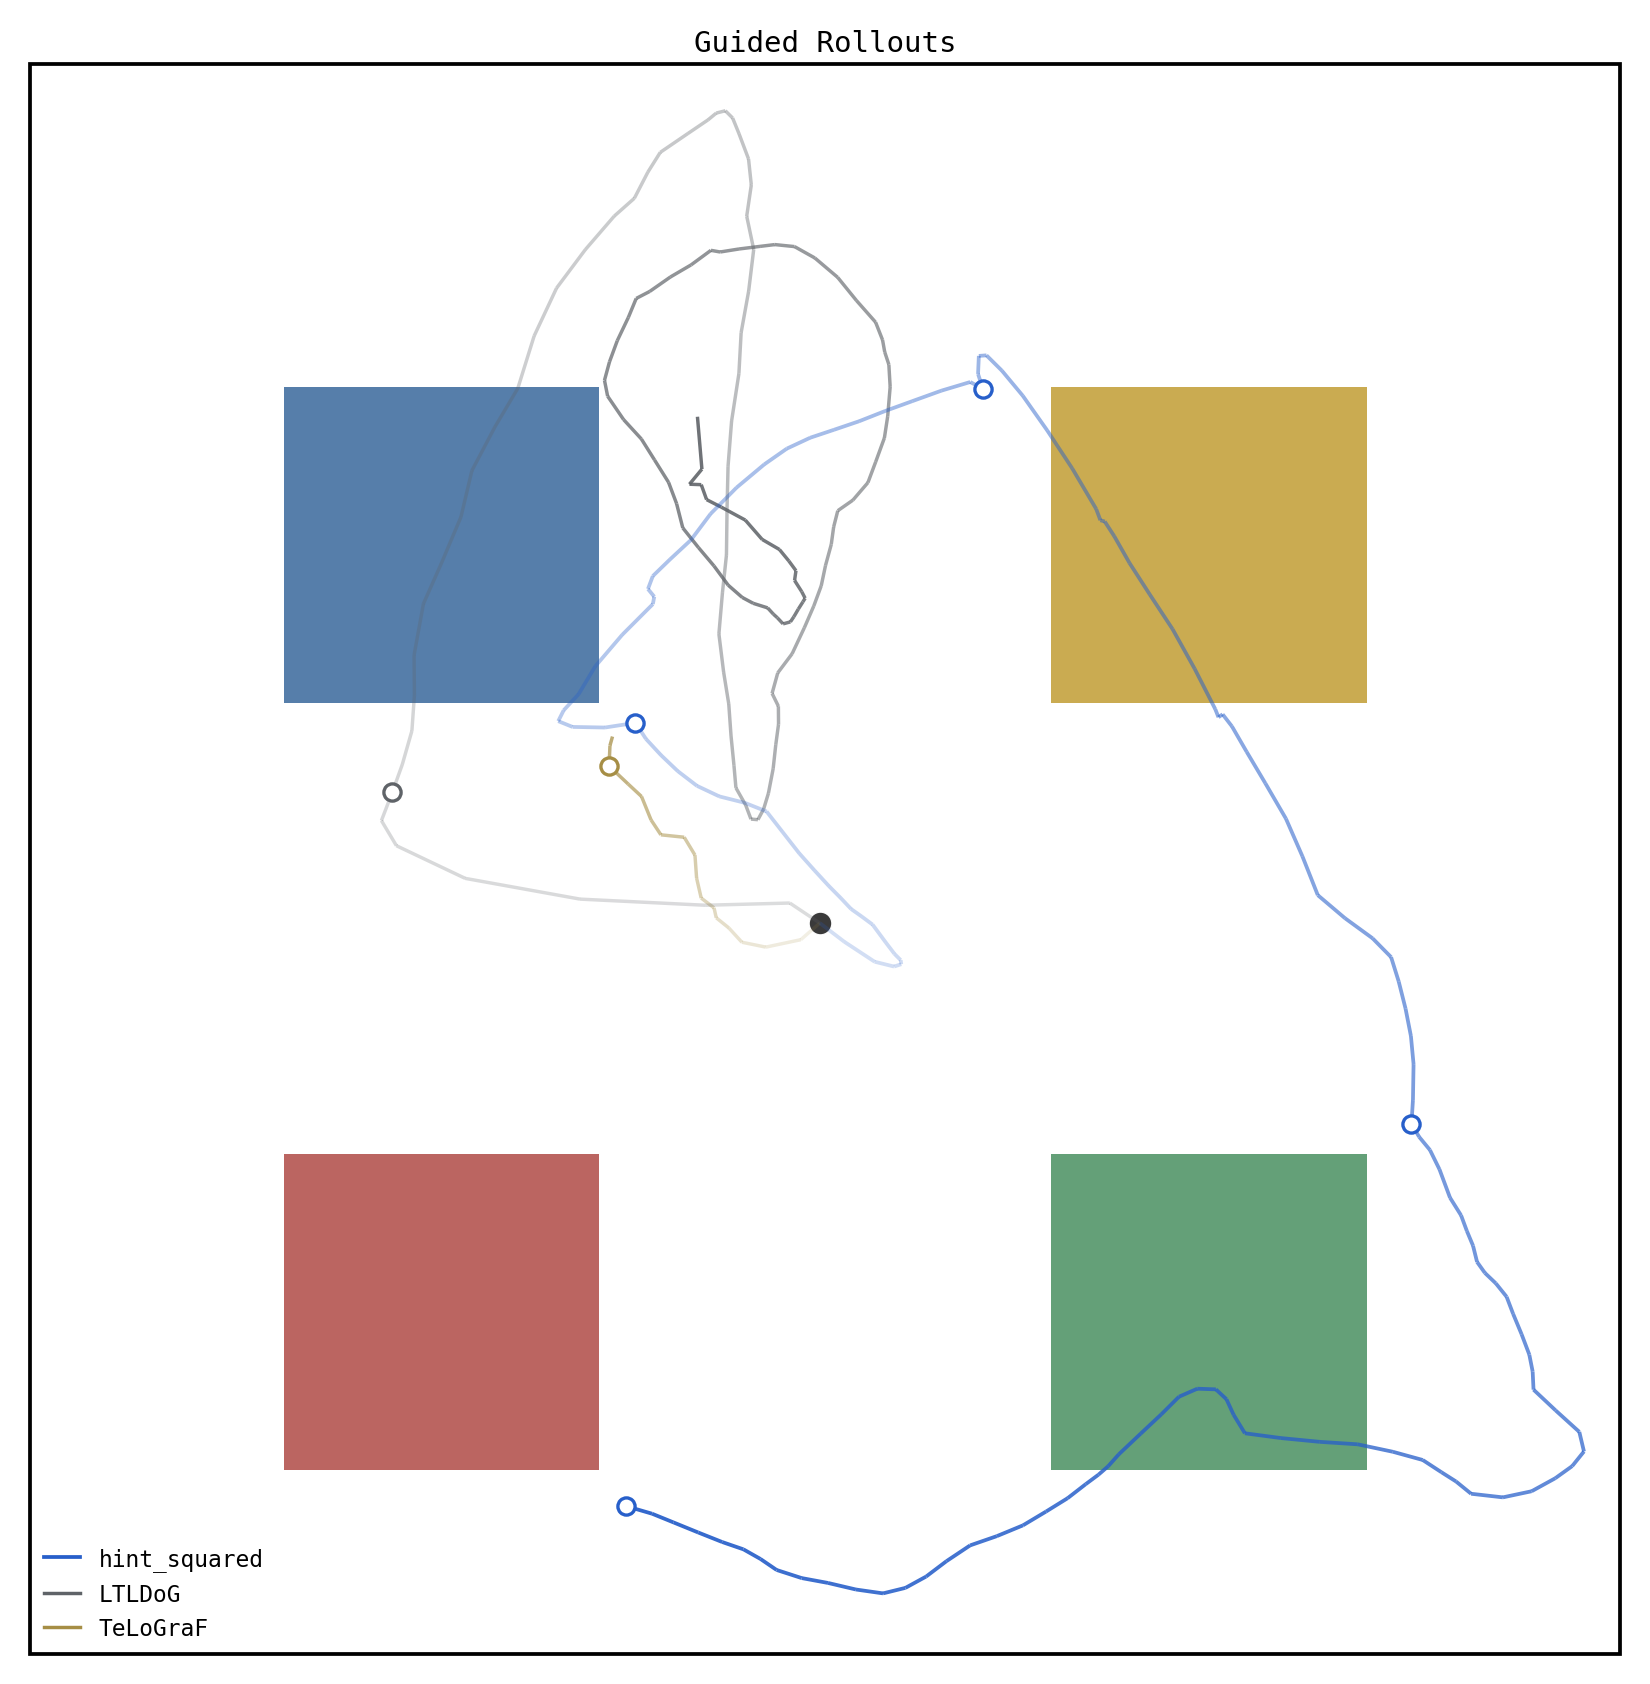

LTLDoG example: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/horizon_03_blue_yellow_green/ltldog_h128_compact_full_exec_tau0p001_scale0p10_g20/rollout_007
hint_squared example: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/horizon_04_blue_yellow_green_red/ours/rollout_000
TeLoGraF example: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/telograf/rollout_007


In [4]:
def first_successful_run(method, horizon):
    summary = method_summary(method, horizon)
    record = next(record for record in summary['records'] if record['complete'])
    return summary, record_run_dir(summary, record)


LTLDOG_EXAMPLE_RUN = RESULT_ROOT / 'horizon_03_blue_yellow_green' / LTLDOG_METHOD / 'rollout_007'
TELOGRAF_EXAMPLE_RUN = REPO_ROOT / 'outputs/toy_squares_rollouts/baseline_ltldog/telograf/rollout_007'


def plot_example_overlay_panel(ax, legend=True):
    ltldog_run = LTLDOG_EXAMPLE_RUN
    ours_h4, ours_run = first_successful_run('ours', 4)
    telograf_run = TELOGRAF_EXAMPLE_RUN if INCLUDE_TELOGRAF else None

    ltldog_actual = load_trajectory(ltldog_run)
    ours_actual = load_trajectory(ours_run)
    telograf_actual = load_trajectory(telograf_run) if telograf_run is not None else None
    setup_state = np.load(ltldog_run / 'setup_state.npy')

    trajectories_for_zoom = [traj for traj in [telograf_actual, ltldog_actual, ours_actual] if traj is not None]
    style_env_axis(ax, setup_state, trajectories=trajectories_for_zoom, pad=0.13, min_half_width=0.50,
                   title='Guided Rollouts')

    if telograf_actual is not None:
        faded_path(ax, telograf_actual, TELOGRAF_COLOR, linewidth=0.825, alpha=(0.14, 0.74), zorder=6)
        mark_sequence_hits(ax, telograf_run, TELOGRAF_COLOR, text_offset=(-0.020, -0.020), zorder=9)
    faded_path(ax, ltldog_actual, LTLDOG_GRAY, linewidth=0.825, alpha=(0.22, 0.90), zorder=7)
    faded_path(ax, ours_actual, OUR_BLUE, linewidth=0.9, alpha=(0.20, 0.94), zorder=8)
    mark_sequence_hits(ax, ltldog_run, LTLDOG_GRAY, text_offset=(-0.030, 0.014))
    mark_sequence_hits(ax, ours_run, OUR_BLUE, text_offset=(0.014, -0.030))

    if legend:
        handles = [
            Line2D([0], [0], color=OUR_BLUE, lw=0.9, label='hint_squared'),
            Line2D([0], [0], color=LTLDOG_GRAY, lw=0.825, label='LTLDoG'),
        ]
        if INCLUDE_TELOGRAF:
            handles.append(Line2D([0], [0], color=TELOGRAF_COLOR, lw=0.825, label='TeLoGraF'))
        ax.legend(handles=handles, loc='lower left', frameon=False, handlelength=1.6, borderaxespad=0.2)
    return ltldog_run, ours_run, telograf_run


fig, ax = plt.subplots(figsize=(SQUARE_SIDE_IN, SQUARE_SIDE_IN), constrained_layout=True)
ltldog_run, ours_run, telograf_run = plot_example_overlay_panel(ax, legend=True)
save_fig(fig, 'fig4_example_overlay_rollouts', tight=False)
save_fig(fig, 'fig4_example_success_rollouts', tight=False)
plt.show()
print('LTLDoG example:', ltldog_run)
print('hint_squared example:', ours_run)
if telograf_run is not None:
    print('TeLoGraF example:', telograf_run)


## Four-Square Row

This cell lays out the four paper panels as equally tall square axes in one row: satisfaction, rollout length, unguided policy, and guidance rollouts.


In [5]:

# Keep this as an explicit override cell for easy notebook tweaking.
COMMON_ENV_XLIM = (-0.57, 0.57)
COMMON_ENV_YLIM = (-0.52, 0.62)
AGENT_RADIUS = 0.09
CONTACT_DOT_RADIUS = 0.035
CONTACT_DOT_MARKER_SIZE = 17
BLOCK_BASE_RADIUS = 0.125
BLOCK_RADIUS = BLOCK_BASE_RADIUS + AGENT_RADIUS - CONTACT_DOT_RADIUS + 0.03

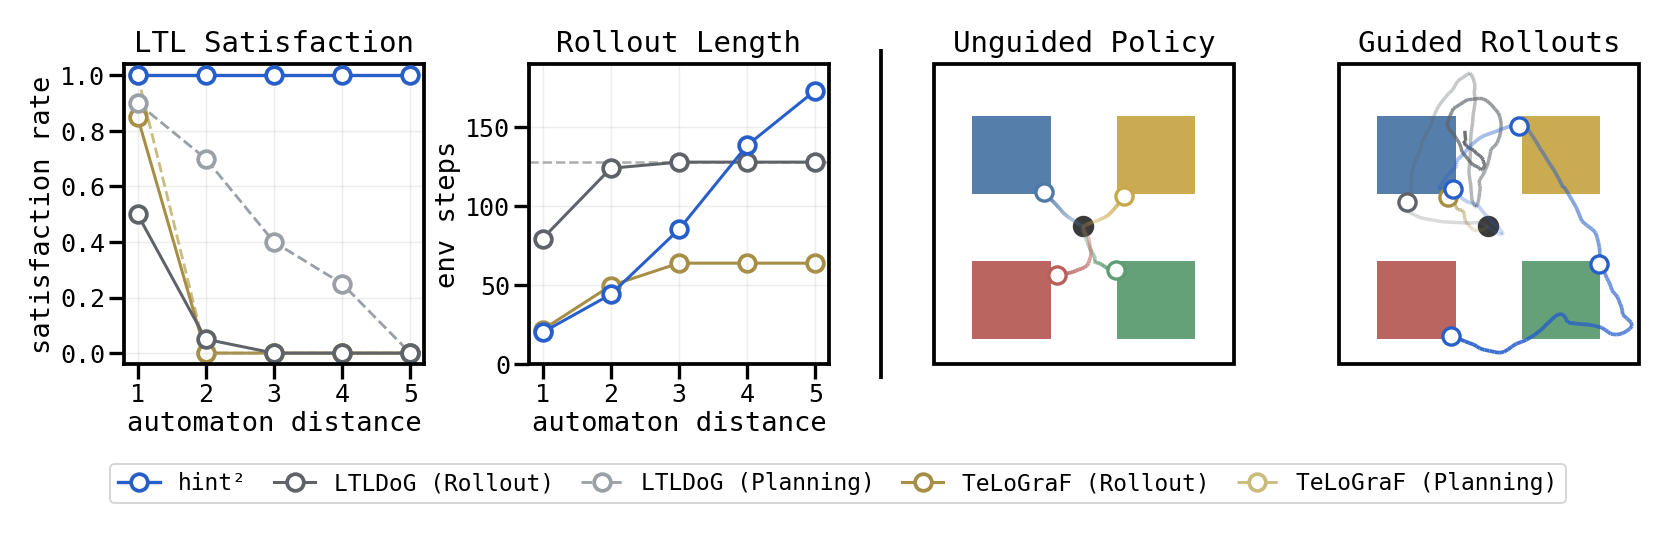

saved: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/paperplots/fig5_three_square_strip.png


In [6]:
def add_axes_in_inches(fig, left, bottom, width, height):
    fig_w, fig_h = fig.get_size_inches()
    return fig.add_axes([left / fig_w, bottom / fig_h, width / fig_w, height / fig_h])


def add_vertical_separator_in_inches(fig, x, bottom, top, linewidth=PANEL_FRAME_LW):
    fig_w, fig_h = fig.get_size_inches()
    separator = Line2D([x / fig_w, x / fig_w], [bottom / fig_h, top / fig_h],
                       transform=fig.transFigure, color='black', linewidth=linewidth,
                       solid_capstyle='butt', clip_on=False, zorder=30)
    fig.add_artist(separator)
    return separator


def add_equal_square_row(fig):
    side = FOUR_PANEL_AXIS_SIDE_IN
    gap = FOUR_PANEL_FRAME_GAP_IN
    left = FOUR_PANEL_LEFT_MARGIN_IN
    bottom = FOUR_PANEL_AXIS_BOTTOM_IN

    success_left = left
    steps_left = success_left + side + gap
    base_left = steps_left + side + gap
    example_left = base_left + side + gap

    separator_x = steps_left + side + 0.5 * gap
    add_vertical_separator_in_inches(
        fig,
        separator_x,
        bottom + FOUR_PANEL_SEPARATOR_BOTTOM_INSET_IN,
        bottom + side - FOUR_PANEL_SEPARATOR_TOP_INSET_IN,
    )

    return (
        add_axes_in_inches(fig, success_left, bottom, side, side),
        add_axes_in_inches(fig, steps_left, bottom, side, side),
        add_axes_in_inches(fig, base_left, bottom, side, side),
        add_axes_in_inches(fig, example_left, bottom, side, side),
    )


fig = plt.figure(figsize=(TEXTWIDTH_IN, FOUR_SQUARE_ROW_HEIGHT_IN), constrained_layout=False)
ax_success, ax_steps, ax_base, ax_example = add_equal_square_row(fig)

plot_success_axis(ax_success, legend=False, compact=True)
plot_steps_axis(ax_steps, legend=False, compact=True)
plot_base_dp_panel(ax_base, legend=False)
plot_example_overlay_panel(ax_example, legend=False)
legend_handles = paper_legend_handles()
legend = fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.075),
                    ncol=len(legend_handles), frameon=True, fancybox=True, framealpha=1.0,
                    edgecolor='#d4d4d4', facecolor='white', handlelength=1.8,
                    handleheight=0.75, columnspacing=1.2, borderpad=0.35,
                    borderaxespad=0.0)
legend.get_frame().set_linewidth(0.45)

save_fig_vertical_crop(fig, 'fig5_four_panel_square', FOUR_PANEL_CROP_BOTTOM_IN, FOUR_PANEL_CROP_TOP_IN)
save_fig_vertical_crop(fig, 'fig5_four_square_row', FOUR_PANEL_CROP_BOTTOM_IN, FOUR_PANEL_CROP_TOP_IN)
save_fig_vertical_crop(fig, 'fig5_three_square_strip', FOUR_PANEL_CROP_BOTTOM_IN, FOUR_PANEL_CROP_TOP_IN)
plt.show()
print('saved:', PLOT_DIR / 'fig5_three_square_strip.png')
